# PHQ-8 Depression Detection — HuBERT + Attention Pooling + MLP (Classification)

**Architecture**: Frozen HuBERT (`facebook/hubert-base-ls960`) → sequence of mean-pooled 768-dim segment features → **Learned Attention Pooling** → 768-dim participant vector → `MLP(768→128→1)` → binary logit.

**Task**: Binary classification — depressed (PHQ-8 ≥ 10) vs. control (PHQ-8 < 10).

**Why Attention + MLP over BiLSTM**:
- AVEC 2017 has only ~83 training participants — too few for a recurrent model to generalise.
- Depression is a *statistical* property of speech (not a temporal trajectory), so an attention-weighted mean is a better inductive bias than an LSTM.
- Attention pooling learns *which segments are most informative* per participant, making predictions interpretable.
- Far fewer parameters → less overfitting on small data.

**Feature reuse**: shares `processed/hubert_features_cls.npz` with the BiLSTM notebook — no re-extraction needed.

**Input**: Sequence of 768-dim HuBERT features, one per 8-second window (4-second hop, 50% overlap).

**Target**: Binary label — 0 (control) or 1 (depressed).

## 1. Install Dependencies

In [28]:
!pip install transformers librosa tqdm pandas numpy scikit-learn --quiet
print("All packages ready.")

All packages ready.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports & Configuration

In [29]:
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
from torch.optim import Adam

import librosa
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report
)
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("Imports successful.")

Imports successful.


In [30]:
# --- Paths ---
BASE_DIR      = Path("..")
DATASET_DIR   = BASE_DIR / "dataset"
PROCESSED_DIR = BASE_DIR / "processed"

TRAIN_CSV = DATASET_DIR / "train_split_Depression_AVEC2017.csv"
DEV_CSV   = DATASET_DIR / "dev_split_Depression_AVEC2017.csv"
TEST_CSV  = DATASET_DIR / "full_test_split.csv"

# Reuse the same HuBERT feature cache from the BiLSTM notebook
FEATURE_CACHE = PROCESSED_DIR / "hubert_features_cls.npz"

SAVE_DIR = BASE_DIR / "experiments" / "best_model" / "hubert_mlp_cls"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# --- Device ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device   : {DEVICE}")
print(f"Feature cache  : {FEATURE_CACHE.resolve()}")
print(f"Checkpoint dir : {SAVE_DIR.resolve()}")

Using device   : cuda
Feature cache  : C:\Users\edgar\OneDrive\Documents\Term_8\Deep_learning\Project\phq8_depression_detection\processed\hubert_features_cls.npz
Checkpoint dir : C:\Users\edgar\OneDrive\Documents\Term_8\Deep_learning\Project\phq8_depression_detection\experiments\best_model\hubert_mlp_cls


## 3. Load Label Files

Binary labels:
- `PHQ8_Binary` in train/dev CSVs — 1 if PHQ-8 ≥ 10, else 0
- `PHQ_Binary` in test CSV (same threshold, different column name)

In [31]:
train_df = pd.read_csv(TRAIN_CSV)[["Participant_ID", "PHQ8_Binary"]]
dev_df   = pd.read_csv(DEV_CSV)[["Participant_ID", "PHQ8_Binary"]]
test_df  = pd.read_csv(TEST_CSV)[["Participant_ID", "PHQ_Binary"]].rename(
    columns={"PHQ_Binary": "PHQ8_Binary"}
)

train_labels = dict(zip(train_df.Participant_ID, train_df.PHQ8_Binary))
dev_labels   = dict(zip(dev_df.Participant_ID,   dev_df.PHQ8_Binary))
test_labels  = dict(zip(test_df.Participant_ID,  test_df.PHQ8_Binary))

pid_to_label = {**train_labels, **dev_labels, **test_labels}
pid_to_split = (
    {pid: "train" for pid in train_labels}
    | {pid: "dev"   for pid in dev_labels}
    | {pid: "test"  for pid in test_labels}
)

for name, labels in [("Train", train_labels), ("Dev", dev_labels), ("Test", test_labels)]:
    dep  = sum(labels.values())
    ctrl = len(labels) - dep
    print(f"{name:5s}: {len(labels):3d} participants  "
          f"depressed: {dep}  control: {ctrl}")

Train: 107 participants  depressed: 30  control: 77
Dev  :  35 participants  depressed: 12  control: 23
Test :  47 participants  depressed: 14  control: 33


## 4. Feature Extraction

Audio files are segmented into **8-second windows** with a **4-second (50%) hop**.
Each segment is passed through frozen HuBERT and mean-pooled → **768-dim feature vector**.

If `hubert_features_cls.npz` already exists (from the BiLSTM notebook), extraction is skipped.

In [32]:
SR              = 16_000
WIN_SEC         = 8
HOP_SEC         = 4
WIN_SAMPLES     = WIN_SEC * SR
HOP_SAMPLES     = HOP_SEC * SR
HUBERT_MODEL_ID = "facebook/hubert-base-ls960"

if FEATURE_CACHE.exists():
    print(f"Feature cache found at {FEATURE_CACHE.name} — skipping extraction.")
else:
    print(f"Extracting HuBERT features → {FEATURE_CACHE.name}")
    from transformers import HubertModel, Wav2Vec2FeatureExtractor

    feat_extractor = Wav2Vec2FeatureExtractor.from_pretrained(HUBERT_MODEL_ID)
    hubert = HubertModel.from_pretrained(HUBERT_MODEL_ID)
    hubert.eval().to(DEVICE)
    for param in hubert.parameters():
        param.requires_grad = False
    print("HuBERT loaded and frozen.")

    all_feats, all_bin_labels, all_pids, all_splits = [], [], [], []
    audio_files = sorted(DATASET_DIR.glob("*_P.wav"))
    print(f"\nProcessing {len(audio_files)} audio files ...")

    for wav_path in tqdm(audio_files):
        pid = int(wav_path.stem.split("_")[0])
        if pid not in pid_to_label:
            continue
        split = pid_to_split[pid]
        label = pid_to_label[pid]
        audio, _ = librosa.load(str(wav_path), sr=SR, mono=True)

        starts = list(range(0, len(audio) - WIN_SAMPLES + 1, HOP_SAMPLES))
        if not starts:
            audio  = np.pad(audio, (0, WIN_SAMPLES - len(audio)))
            starts = [0]

        for start in starts:
            seg    = audio[start : start + WIN_SAMPLES]
            inputs = feat_extractor(
                seg.tolist(), sampling_rate=SR, return_tensors="pt", padding=True
            )
            with torch.no_grad():
                hidden = hubert(inputs.input_values.to(DEVICE)).last_hidden_state
            feat = hidden.mean(dim=1).squeeze(0).cpu().numpy()

            all_feats.append(feat)
            all_bin_labels.append(label)
            all_pids.append(pid)
            all_splits.append(split.encode())

    np.savez_compressed(
        FEATURE_CACHE,
        feats         = np.array(all_feats,      dtype=np.float32),
        binary_labels = np.array(all_bin_labels, dtype=np.int32),
        pids          = np.array(all_pids,        dtype=np.int32),
        splits        = np.array(all_splits),
    )
    print(f"\nSaved {len(all_feats):,} segment features → {FEATURE_CACHE}")
    del hubert, feat_extractor
    torch.cuda.empty_cache()

Feature cache found at hubert_features_cls.npz — skipping extraction.


## 5. Build Participant-Level Dataset

Load cached features and group segments by participant.
The attention layer will learn to weight segments — no ordering assumption needed.

In [33]:
print(f"Loading features from {FEATURE_CACHE.name} ...")
cache           = np.load(FEATURE_CACHE, allow_pickle=False)
all_feats_np    = cache["feats"]
all_labels_np   = cache["binary_labels"]
all_pids_np     = cache["pids"]
all_splits_np   = cache["splits"]

in_memory = {
    "train": defaultdict(lambda: {"feats": [], "label": None}),
    "dev":   defaultdict(lambda: {"feats": [], "label": None}),
    "test":  defaultdict(lambda: {"feats": [], "label": None}),
}

for feat, lbl, pid, split_b in zip(
    all_feats_np, all_labels_np, all_pids_np, all_splits_np
):
    split = split_b.decode()
    pid   = int(pid)
    in_memory[split][pid]["feats"].append(feat)
    in_memory[split][pid]["label"] = int(lbl)

splits_list = {s: list(in_memory[s].items()) for s in ("train", "dev", "test")}

print(f"\n{'Split':10s}  {'Participants':>12}  {'Segments':>8}  {'Depressed':>9}  {'Control':>7}")
print("-" * 52)
for s, name in [("train", "train"), ("dev", "validation"), ("test", "test")]:
    n_segs = sum(len(d["feats"]) for _, d in splits_list[s])
    n_dep  = sum(d["label"] for _, d in splits_list[s])
    n_ctrl = len(splits_list[s]) - n_dep
    print(f"{name:10s}  {len(splits_list[s]):12d}  {n_segs:8,}  {n_dep:9d}  {n_ctrl:7d}")

Loading features from hubert_features_cls.npz ...

Split       Participants  Segments  Depressed  Control
----------------------------------------------------
train                107    11,362         30       77
validation            35     4,322         12       23
test                  47     5,904         14       33


## 6. Training Configuration

In [41]:
# --- Model hyper-parameters ---
HUBERT_DIM  = 768
MLP_HIDDEN  = 256   # hidden units in the MLP head
DROPOUT     = 0.3  # lighter regularisation for small dataset

# --- Training hyper-parameters ---
PARTICIPANT_BATCH_SIZE  = 16
NUM_EPOCHS              = 500
LEARNING_RATE           = 1e-4
WEIGHT_DECAY            = 1e-4   # lighter than BiLSTM notebook (was 1e-3)
EARLY_STOPPING_PATIENCE = 50
CHECKPOINT_FREQ         = 50
GRAD_CLIP_NORM          = 1.0

print("Training configuration:")
print(f"  MLP hidden dim         : {MLP_HIDDEN}")
print(f"  Dropout                : {DROPOUT}")
print(f"  Participant batch size : {PARTICIPANT_BATCH_SIZE}")
print(f"  Epochs                 : {NUM_EPOCHS}")
print(f"  Learning rate          : {LEARNING_RATE}")
print(f"  Weight decay           : {WEIGHT_DECAY}")
print(f"  Early stopping         : {EARLY_STOPPING_PATIENCE} epochs patience")
print(f"  Grad clip norm         : {GRAD_CLIP_NORM}")

Training configuration:
  MLP hidden dim         : 256
  Dropout                : 0.3
  Participant batch size : 16
  Epochs                 : 500
  Learning rate          : 0.0001
  Weight decay           : 0.0001
  Early stopping         : 50 epochs patience
  Grad clip norm         : 1.0


## 7. Model — HuBERT Attention Pooling + MLP Classifier

```
Input  : (T, 768)   — segment features for one participant
         ↓ Linear(768, 1) + softmax over T
         ↓ attention-weighted sum → (768,)   [learned segment importance]
         ↓ Linear(768, 128) + ReLU
         ↓ Dropout(0.25)
         ↓ Linear(128, 1)
Output : scalar logit  (sigmoid → probability of depression)
```

The attention scorer assigns a weight to each segment — segments with more
discriminative speech patterns receive higher weight. The MLP then classifies
the resulting participant-level vector.

In [42]:
class HuBERTAttentionMLPClassifier(nn.Module):
    """
    Attention pooling + LayerNorm + MLP binary classifier on top of frozen HuBERT features.

    Input  : (T, 768)  — segment features for one participant
    Output : scalar logit  — positive = depressed, negative = control
    """
    def __init__(
        self,
        input_dim:  int   = HUBERT_DIM,
        hidden_dim: int   = MLP_HIDDEN,
        dropout:    float = DROPOUT,
    ):
        super().__init__()
        # Learns a scalar importance score per segment
        self.attention  = nn.Linear(input_dim, 1)
        # Normalise the pooled vector before classification
        self.norm       = nn.LayerNorm(input_dim)
        # MLP classification head
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x : (T, 768)
        attn_weights = torch.softmax(self.attention(x), dim=0)  # (T, 1)
        pooled       = (attn_weights * x).sum(dim=0)            # (768,)
        pooled       = self.norm(pooled)                        # (768,)  normalised
        return self.classifier(pooled).squeeze()                # scalar logit


model = HuBERTAttentionMLPClassifier().to(DEVICE)

# Sanity-check forward pass
with torch.no_grad():
    dummy = torch.zeros(10, HUBERT_DIM, device=DEVICE)
    out   = model(dummy)
    print(f"Output shape (10 segments): {out.shape}  (expected: torch.Size([]))")

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")


Output shape (10 segments): torch.Size([])  (expected: torch.Size([]))
Trainable parameters: 199,426


## 8. Training Loop

**Participant-level training**: each participant's segments are fed as a set → attention pooling → one logit → `BCEWithLogitsLoss`.

**Class-weighted loss**: `pos_weight = n_control / n_depressed` compensates for class imbalance.

**Threshold tuning**: after training, the decision threshold is tuned on the validation set to maximise F1.

In [43]:
# ── Class-weighted loss ───────────────────────────────────────────────────────
n_dep_train  = sum(d["label"] for _, d in splits_list["train"])
n_ctrl_train = len(splits_list["train"]) - n_dep_train
pos_weight   = torch.tensor(n_ctrl_train / n_dep_train, dtype=torch.float32, device=DEVICE)
print(f"Training class counts — depressed: {n_dep_train}, control: {n_ctrl_train}")
print(f"BCEWithLogitsLoss pos_weight: {pos_weight.item():.4f}")

criterion          = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer          = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [],
}
best_val_loss      = float("inf")
epochs_no_improve  = 0
train_participants = splits_list["train"]


def train_epoch():
    model.train()
    idx     = torch.randperm(len(train_participants)).tolist()
    batches = [
        idx[i : i + PARTICIPANT_BATCH_SIZE]
        for i in range(0, len(idx), PARTICIPANT_BATCH_SIZE)
    ]
    total_loss = 0.0
    correct    = 0
    n          = len(train_participants)

    for batch in batches:
        optimizer.zero_grad()
        batch_size = len(batch)

        for i in batch:
            _, data = train_participants[i]
            feats = torch.tensor(
                np.array(data["feats"]), dtype=torch.float32, device=DEVICE
            )
            label = torch.tensor(
                float(data["label"]), dtype=torch.float32, device=DEVICE
            )

            logit = model(feats)
            loss  = criterion(logit, label) / batch_size
            loss.backward()

            total_loss += loss.item() * batch_size
            pred        = 1 if torch.sigmoid(logit).item() >= 0.5 else 0
            correct    += int(pred == data["label"])

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
        optimizer.step()

    return total_loss / n, correct / n


def evaluate(split: str, threshold: float = 0.5):
    model.eval()
    total_loss = 0.0
    correct    = 0
    records    = []

    with torch.no_grad():
        for pid, data in splits_list[split]:
            feats = torch.tensor(
                np.array(data["feats"]), dtype=torch.float32, device=DEVICE
            )
            label = torch.tensor(
                float(data["label"]), dtype=torch.float32, device=DEVICE
            )

            logit      = model(feats)
            loss       = criterion(logit, label)
            total_loss += loss.item()

            pred_prob = torch.sigmoid(logit).item()
            pred      = 1 if pred_prob >= threshold else 0
            correct  += int(pred == data["label"])
            records.append((pid, pred, pred_prob, data["label"]))

    n  = len(splits_list[split])
    df = pd.DataFrame(records, columns=["participant_id", "pred", "pred_prob", "label"])
    return total_loss / n, correct / n, df


# ── Training ──────────────────────────────────────────────────────────────────
print(f"\nTraining on {len(train_participants)} participants for up to {NUM_EPOCHS} epochs.")
print()
print(f"{'Epoch':>6}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>8}  {'Val Acc':>7}")
print("-" * 52)

for epoch in range(1, NUM_EPOCHS + 1):

    train_loss, train_acc    = train_epoch()
    val_loss,   val_acc, _   = evaluate("dev")

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"{epoch:6d}  {train_loss:10.4f}  {train_acc:9.4f}  {val_loss:8.4f}  {val_acc:7.4f}")

    if epoch % CHECKPOINT_FREQ == 0:
        ckpt_path = SAVE_DIR / f"epoch{epoch}_HuBERT_MLP_cls.pth"
        torch.save({
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_loss":           train_loss,
            "val_loss":             val_loss,
        }, ckpt_path)

    if val_loss < best_val_loss:
        best_val_loss     = val_loss
        epochs_no_improve = 0
        best_path = SAVE_DIR / "HuBERT_MLP_cls_best.pth"
        torch.save({
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss":             val_loss,
            "val_acc":              val_acc,
        }, best_path)
        print(f"  *** Best model saved  "
              f"val loss {val_loss:.4f}  val acc {val_acc:.4f} ***")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
            print(f"\nEarly stopping at epoch {epoch} — "
                  f"no improvement for {EARLY_STOPPING_PATIENCE} epochs.")
            break

print("\nTraining complete.")
best_epoch_idx = history["val_loss"].index(min(history["val_loss"]))
print(f"Best val loss     : {min(history['val_loss']):.4f}  (epoch {best_epoch_idx + 1})")
print(f"Best val accuracy : {history['val_acc'][best_epoch_idx]:.4f}")

# ── Threshold tuning on validation set ───────────────────────────────────────
best_ckpt = torch.load(
    SAVE_DIR / "HuBERT_MLP_cls_best.pth",
    map_location=DEVICE,
    weights_only=True,
)
model.load_state_dict(best_ckpt["model_state_dict"])

_, _, val_df = evaluate("dev", threshold=0.5)
best_thresh, best_val_f1 = 0.5, 0.0
for thresh in np.arange(0.1, 0.91, 0.05):
    y_t = val_df["label"].values.astype(int)
    y_p = (val_df["pred_prob"].values >= thresh).astype(int)
    f1  = f1_score(y_t, y_p, average="macro", zero_division=0)
    if f1 > best_val_f1:
        best_val_f1  = f1
        best_thresh  = float(thresh)

print(f"\nThreshold tuned on validation set → {best_thresh:.2f}  (val macro-F1 = {best_val_f1:.4f})")


Training class counts — depressed: 30, control: 77
BCEWithLogitsLoss pos_weight: 2.5667

Training on 107 participants for up to 500 epochs.

 Epoch  Train Loss  Train Acc  Val Loss  Val Acc
----------------------------------------------------
     1      0.9927     0.5234    1.0912   0.6571
  *** Best model saved  val loss 1.0912  val acc 0.6571 ***
     2      1.0264     0.5701    1.0860   0.6571
  *** Best model saved  val loss 1.0860  val acc 0.6571 ***
     3      0.9971     0.5607    1.0670   0.5714
  *** Best model saved  val loss 1.0670  val acc 0.5714 ***
     4      0.9958     0.6355    1.0768   0.6286
     5      0.9618     0.7757    1.0811   0.6571
     6      0.9482     0.7850    1.0826   0.6571
     7      0.9627     0.7103    1.0595   0.6286
  *** Best model saved  val loss 1.0595  val acc 0.6286 ***
     8      0.9456     0.6542    1.0447   0.4857
  *** Best model saved  val loss 1.0447  val acc 0.4857 ***
     9      0.9311     0.6168    1.0466   0.5714
    10      0.93

## 9. Training Curves

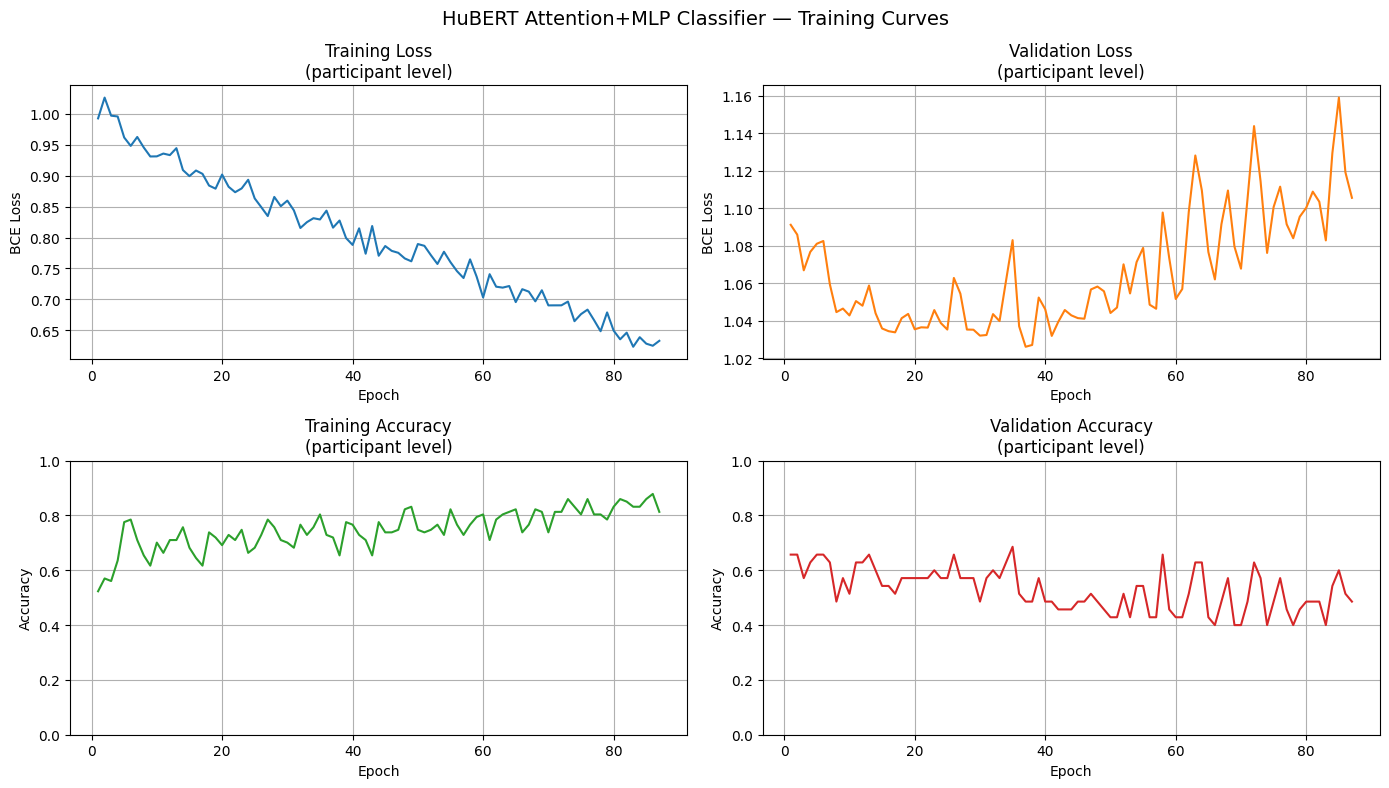

In [44]:
epochs_ran = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(epochs_ran, history["train_loss"], color="tab:blue")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("BCE Loss")
axes[0, 0].set_title("Training Loss\n(participant level)")
axes[0, 0].grid(True)

axes[0, 1].plot(epochs_ran, history["val_loss"], color="tab:orange")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("BCE Loss")
axes[0, 1].set_title("Validation Loss\n(participant level)")
axes[0, 1].grid(True)

axes[1, 0].plot(epochs_ran, history["train_acc"], color="tab:green")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Accuracy")
axes[1, 0].set_title("Training Accuracy\n(participant level)")
axes[1, 0].set_ylim(0, 1)
axes[1, 0].grid(True)

axes[1, 1].plot(epochs_ran, history["val_acc"], color="tab:red")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Accuracy")
axes[1, 1].set_title("Validation Accuracy\n(participant level)")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].grid(True)

plt.suptitle("HuBERT Attention+MLP Classifier — Training Curves", fontsize=14)
plt.tight_layout()
plt.show()

## 10. Attention Weight Visualisation

Inspect which segments the model attends to for a sample of participants.
High-weight segments are the ones most influential to the classification decision.

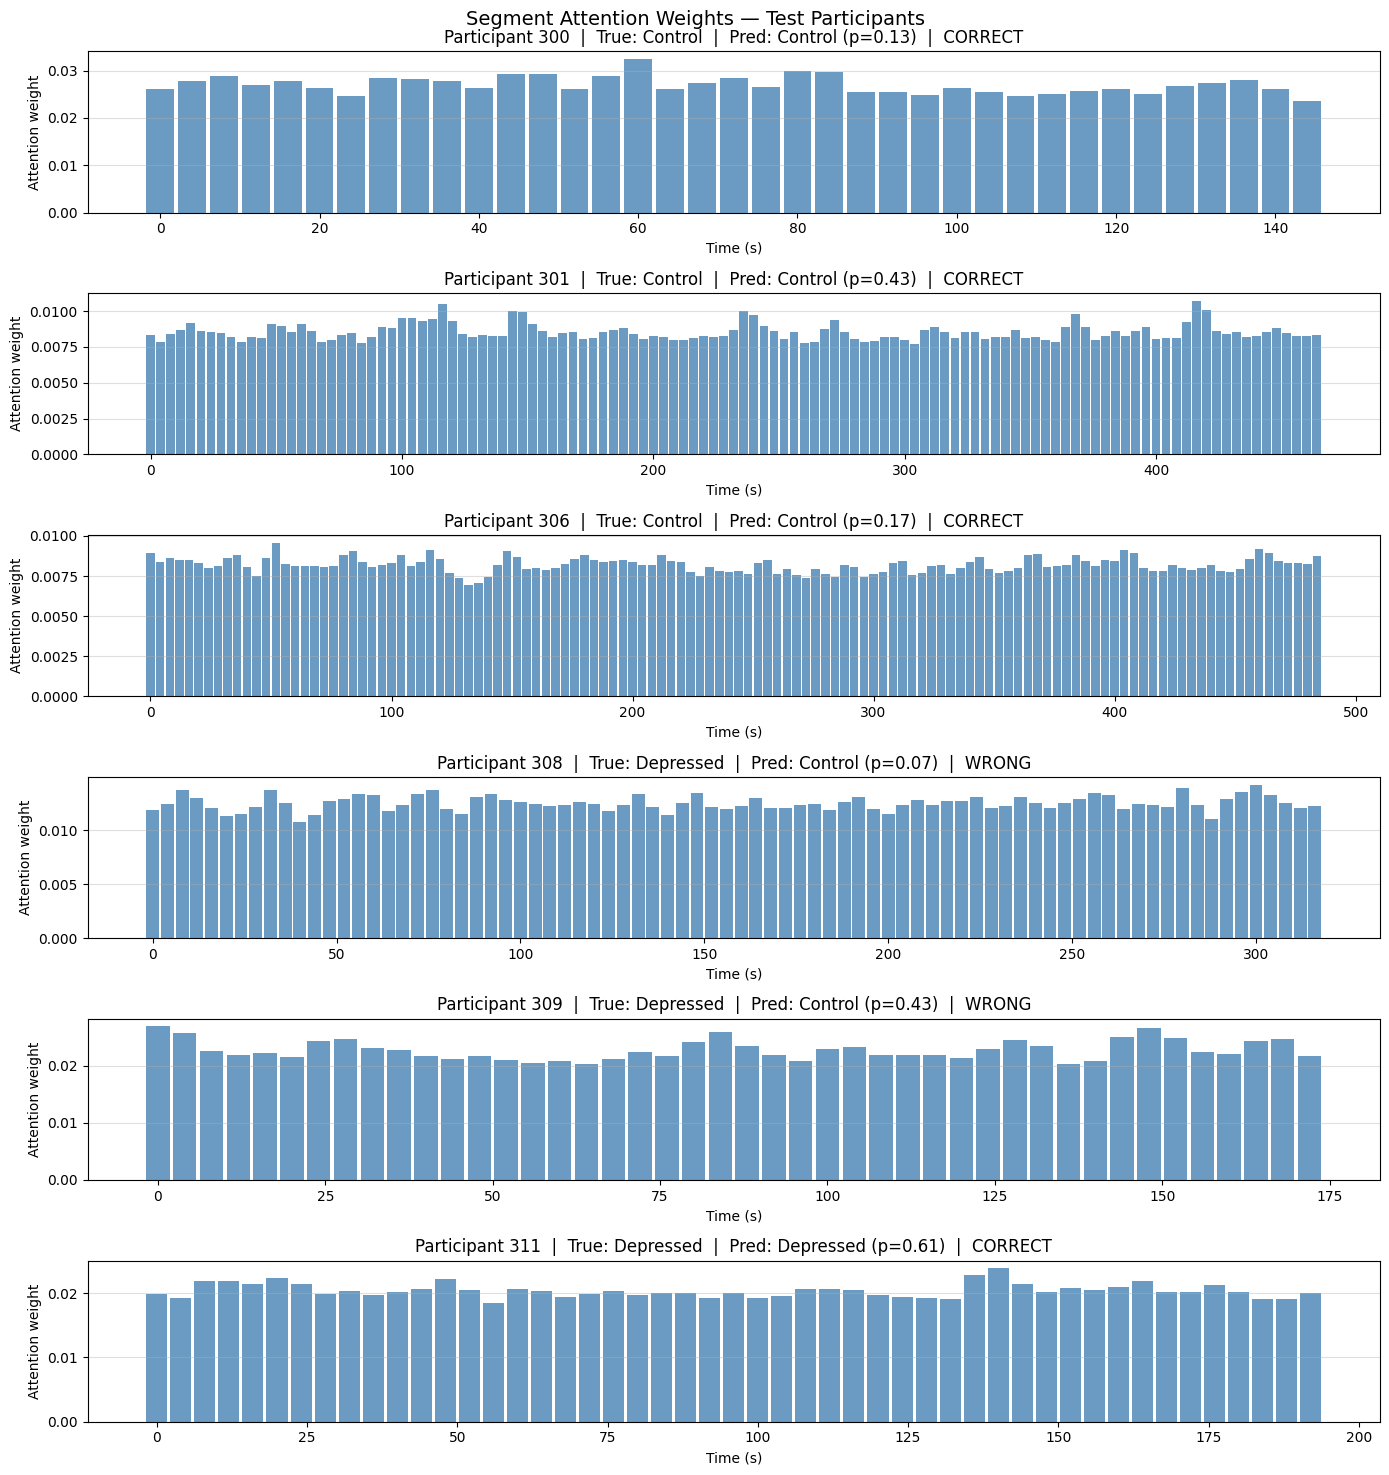

In [45]:
model.eval()
n_show = min(6, len(splits_list["test"]))
fig, axes = plt.subplots(n_show, 1, figsize=(14, 2.5 * n_show))
if n_show == 1:
    axes = [axes]

with torch.no_grad():
    for ax, (pid, data) in zip(axes, splits_list["test"][:n_show]):
        feats = torch.tensor(
            np.array(data["feats"]), dtype=torch.float32, device=DEVICE
        )
        attn_weights = torch.softmax(
            model.attention(feats), dim=0
        ).squeeze().cpu().numpy()   # (T,)

        logit     = model(feats)
        pred_prob = torch.sigmoid(logit).item()
        pred      = 1 if pred_prob >= best_thresh else 0
        true_lbl  = data["label"]

        time_axis = np.arange(len(attn_weights)) * 4   # 4-second hop
        ax.bar(time_axis, attn_weights, width=3.5, color="steelblue", alpha=0.8)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Attention weight")
        status = "CORRECT" if pred == true_lbl else "WRONG"
        label_str = "Depressed" if true_lbl == 1 else "Control"
        pred_str  = "Depressed" if pred == 1 else "Control"
        ax.set_title(
            f"Participant {pid}  |  True: {label_str}  |  "
            f"Pred: {pred_str} (p={pred_prob:.2f})  |  {status}"
        )
        ax.grid(True, axis="y", alpha=0.4)

plt.suptitle("Segment Attention Weights — Test Participants", fontsize=14)
plt.tight_layout()
plt.show()

## 11. Evaluation on Test Set

Loads the best checkpoint (lowest validation loss) and reports participant-level
**accuracy, precision, recall, and F1 score** using the validation-tuned threshold.

In [46]:
# best_ckpt and model already loaded + threshold tuned at end of training cell
_, _, test_results_df = evaluate("test", threshold=best_thresh)

y_true = test_results_df["label"].values.astype(int)
y_pred = test_results_df["pred"].values.astype(int)

test_acc  = accuracy_score(y_true, y_pred)
test_prec = precision_score(y_true, y_pred, zero_division=0)
test_rec  = recall_score(y_true, y_pred, zero_division=0)
test_f1   = f1_score(y_true, y_pred, zero_division=0)

print(f"Best checkpoint : epoch {best_ckpt['epoch']}  "
      f"(val loss {best_ckpt['val_loss']:.4f}, val acc {best_ckpt['val_acc']:.4f})")
print(f"Decision threshold: {best_thresh:.2f}  (tuned on validation F1)")
print(f"\nParticipants evaluated: {len(test_results_df)}")
print()
print("── Test-set results (participant level) ──────────────────")
print(f"  Accuracy  : {test_acc:.4f}  "
      f"({int(test_acc * len(y_true))}/{len(y_true)} correct)")
print(f"  Precision : {test_prec:.4f}")
print(f"  Recall    : {test_rec:.4f}")
print(f"  F1 Score  : {test_f1:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=["Control", "Depressed"], zero_division=0))

Best checkpoint : epoch 37  (val loss 1.0263, val acc 0.4857)
Decision threshold: 0.60  (tuned on validation F1)

Participants evaluated: 47

── Test-set results (participant level) ──────────────────
  Accuracy  : 0.6383  (30/47 correct)
  Precision : 0.3846
  Recall    : 0.3571
  F1 Score  : 0.3704

              precision    recall  f1-score   support

     Control       0.74      0.76      0.75        33
   Depressed       0.38      0.36      0.37        14

    accuracy                           0.64        47
   macro avg       0.56      0.56      0.56        47
weighted avg       0.63      0.64      0.63        47



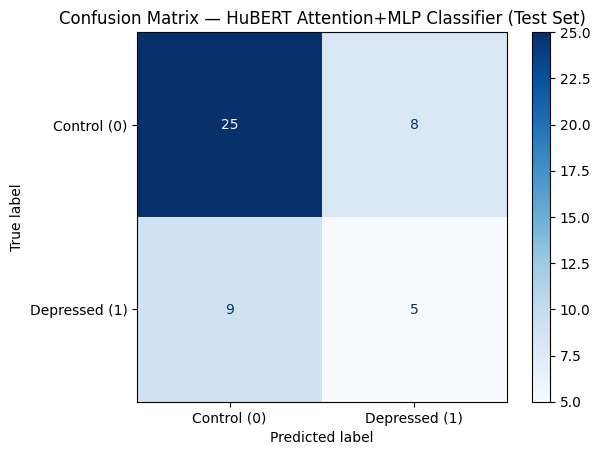

In [47]:
cm   = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Control (0)", "Depressed (1)"]
)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — HuBERT Attention+MLP Classifier (Test Set)")
plt.show()